In [1]:
import sys
import importlib
from pathlib import Path

import numpy as np
import pandas as pd

cwd = Path.cwd().resolve()
repo_root = next((c for c in [cwd, *cwd.parents] if (c / "utilities" / "functions.py").exists()), None)
if repo_root is None:
    raise FileNotFoundError("Could not find the repository root containing utilities/functions.py")
sys.path.append(str(repo_root))

import utilities.functions as functions

importlib.reload(functions)

data_root = repo_root / "ms0_5"
PROTEIN, MIN_POS, MAX_POS = 'RT', 39, 226

ALL_SEQ = functions.read_seq(str(data_root / "RT" / "data" / "rt.reduce4.seq"))
with open(str(data_root / "RT" / "data" / "rt.consensus.reduce4.seq")) as f:
    CONSENSUS = f.read().strip()
REDUX = functions.get_redu_dict(str(data_root / "RT" / "data" / "rt.reduce4.redux"), 0)


def build_J_matrix(j_file, min_position, max_position):
    """Dense coupling tensor, shape (L, L, 4, 5), indexed [p1, p2, aa_at_p1, aa_at_p2]."""
    J = np.load(j_file).astype(np.float32)
    L = max_position - min_position + 1
    Jm = np.zeros((L, L, 4, 5), dtype=np.float32)
    iu0, iu1 = np.triu_indices(L, 1)
    blocks = J.reshape(-1, 4, 4)
    assert blocks.shape[0] == iu0.size, "J.npy row count does not match the position range"
    Jm[iu0, iu1, :, :4] = blocks
    Jm[iu1, iu0, :, :4] = blocks.transpose(0, 2, 1)
    return Jm


J = build_J_matrix(str(data_root / "RT" / "data" / "J_RT.npy"), MIN_POS, MAX_POS)
L = MAX_POS - MIN_POS + 1
print(f"{PROTEIN}: {len(ALL_SEQ):,} sequences, {L} positions")

RT: 19,194 sequences, 188 positions


In [2]:
# ---------------------------------------------------------------------------
# Where the range of dE double comes from, term by term.
#
# For a pair (p1: wt1->mt1, p2: wt2->mt2), dE double splits EXACTLY into one term per
# background position q, plus the direct p1-p2 coupling:
#
#     dE double = sum_{q not in {p1,p2}} c(q)  +  [J(p1,p2,wt1,wt2) - J(p1,p2,mt1,mt2)]
#     c(q)      = [J(p1,q,wt1,s_q) - J(p1,q,mt1,s_q)] + [J(p2,q,wt2,s_q) - J(p2,q,mt2,s_q)]
#
# Every term is a DIFFERENCE of J values, and the only thing that changes from sequence to
# sequence is s_q, the residue the background happens to carry at q. So each position q can
# take just four values -- one per residue A/B/C/D -- and how much q moves dE double depends
# on two things:
#
#     lever   how far apart those four values are (a property of J alone)
#     usage   how often the alignment actually visits the residues that differ
#
# A position with a big lever that is never mutated contributes nothing to the range; a
# position that varies a lot but whose four J differences are equal contributes nothing
# either. Both have to be non-trivial, which is what CVAL and FREQ below separate.
# ---------------------------------------------------------------------------
_AA_CODE = np.full(256, 4, dtype=np.uint8)
for _i, _c in enumerate("ABCD"):
    _AA_CODE[ord(_c)] = _i


def encode_seqs(seq_list, min_pos, max_pos):
    Ln = max_pos - min_pos + 1
    N = len(seq_list)
    raw = np.frombuffer("".join(seq_list).encode(), dtype=np.uint8)
    assert raw.size == N * Ln, "all sequences must span exactly min_pos..max_pos"
    codes = _AA_CODE[raw.reshape(N, Ln)]
    onehot = np.zeros((N * Ln, 5), dtype=np.float32)
    onehot[np.arange(N * Ln), codes.ravel()] = 1.0
    return codes, onehot.reshape(N, Ln * 5)


def _site_energies(onehot, Jm, p, excluded):
    A = Jm[p].copy()
    A[list(excluded)] = 0.0
    return np.asarray(onehot @ A.transpose(0, 2, 1).reshape(-1, 4), dtype=np.float64)


def reduced_idx(pair):
    """'M41L-T215Y' -> (p1, p2, wt1, mt1, wt2, mt2) as 0-based position / residue indices."""
    a, b = functions.split_pairs(pair)
    wt1, pos1, mt1 = functions.split_pair(functions.unreduced_to_reduced(REDUX, a))
    wt2, pos2, mt2 = functions.split_pair(functions.unreduced_to_reduced(REDUX, b))
    return (pos1 - MIN_POS, pos2 - MIN_POS, "ABCD".index(wt1), "ABCD".index(mt1),
            "ABCD".index(wt2), "ABCD".index(mt2))


def decompose(pair, codes, onehot):
    """Per-position J-difference terms for one pair.

    Returns
        C      (N, L)  c(q) for every sequence and position -- the realized terms
        CVAL   (L, 4)  the four values c(q) can take, one per residue at q  (J only)
        de     (N,)    dE double, rebuilt from the terms and checked against the direct route
        direct scalar  the p1-p2 coupling difference, the one term with no background in it
    """
    p1, p2, wt1, mt1, wt2, mt2 = reduced_idx(pair)
    qs = np.arange(L)

    CVAL = ((J[p1][qs[:, None], wt1, np.arange(4)[None, :]]
             - J[p1][qs[:, None], mt1, np.arange(4)[None, :]])
            + (J[p2][qs[:, None], wt2, np.arange(4)[None, :]]
               - J[p2][qs[:, None], mt2, np.arange(4)[None, :]])).astype(np.float64)
    CVAL[[p1, p2]] = 0.0                      # the pair's own positions carry no background term

    C = CVAL[qs[None, :], codes]              # (N, L) realized terms
    direct = float(J[p1, p2, wt1, wt2] - J[p1, p2, mt1, mt2])

    S1 = _site_energies(onehot, J, p1, (p1, p2))
    S2 = _site_energies(onehot, J, p2, (p1, p2))
    J12 = J[p1, p2, :, :4].astype(np.float64)
    M = S1[:, :, None] + S2[:, None, :] + J12[None, :, :]
    de = M[:, wt1, wt2] - M[:, mt1, mt2]
    assert np.allclose(C.sum(axis=1) + direct, de, atol=1e-3), pair
    return C, CVAL, de, direct


print("machinery ready")

machinery ready


In [3]:
# =============================================================================
# The pairs: the top double mutations of RT, read straight off top_20_DRM.txt.
#
# The file lists NRTI pairs first, then NNRTI pairs, with some stray whitespace inside the
# mutation labels ("L74V -Y115F"). A pair is usable here only if both of its positions fall
# inside the Potts model's range (39-226) and both survive the reduced-alphabet lookup; the
# ones that do not are skipped and the list is backfilled from further down the file, so we
# always end up with N_PAIRS rows.
# =============================================================================
N_PAIRS = 20
DRM_FILE = data_root / "RT" / "data" / "top_20_DRM.txt"

raw_pairs = []
for line in DRM_FILE.read_text().splitlines():
    line = line.strip()
    if line:
        raw_pairs.append('-'.join(tok.strip() for tok in line.split('-')))

PAIRS, skipped = [], []
for pair in raw_pairs:
    if len(PAIRS) == N_PAIRS:
        break
    try:
        p1, p2, *_ = reduced_idx(pair)
        if not (0 <= p1 < L and 0 <= p2 < L):
            raise ValueError(f"position outside {MIN_POS}-{MAX_POS}")
        PAIRS.append(pair)
    except Exception as exc:
        skipped.append((pair, str(exc)))

print(f"using {len(PAIRS)} pairs:")
for p in PAIRS:
    print('   ', p)
if skipped:
    print("\nskipped (outside the model range or unparseable):")
    for p, why in skipped:
        print(f'    {p}   {why}')

using 20 pairs:
    F116Y-Q151M
    M41L-T215Y
    K70R-K219E
    D67N-K219Q
    K70R-K219Q
    L210W-T215Y
    F116Y-Q151L
    K65R-S68N
    V75I-F77L
    M41L-T215F
    D67N-K219E
    L210W-T215S
    M41L-T215S
    D67N-K70R
    L74V-Y115F
    L74V-L100I
    A62V-V75I
    F116Y-Q151R
    A62V-V57T
    K101E-G190S

skipped (outside the model range or unparseable):
    V75I-I32L   substring not found


In [4]:
# =============================================================================
# sd of c(q): for one pair and one background position q, how much that position actually
# moves dE double across the alignment.
#
#     c(q) can take only four values -- one per residue A/B/C/D the background may carry at q.
#     sd of c(q) is the spread of the value the alignment REALLY sees, so it folds the J
#     lever and the residue usage into one number. It is zero when the four J differences
#     coincide, and zero again when the alignment never varies at q.
#
# SD is the (pairs x positions) matrix that gets drawn. The pair's own two positions carry no
# background term at all, so they are held at 0 by decompose() and masked out of the heat map
# rather than shown as "no leverage".
# =============================================================================
CODES, ONEHOT = encode_seqs(ALL_SEQ, MIN_POS, MAX_POS)
POSITIONS = np.arange(MIN_POS, MAX_POS + 1)

SD = np.zeros((len(PAIRS), L), dtype=np.float64)
SELF_POS = {}
for i, pair in enumerate(PAIRS):
    C, CVAL, de, direct = decompose(pair, CODES, ONEHOT)
    SD[i] = C.std(axis=0)
    p1, p2, *_ = reduced_idx(pair)
    SELF_POS[pair] = (p1, p2)

SD_TABLE = pd.DataFrame(SD, index=PAIRS, columns=POSITIONS)

summary = pd.DataFrame({
    'pair': PAIRS,
    'max sd of c(q)': SD.max(axis=1),
    'position of max': POSITIONS[SD.argmax(axis=1)],
    'positions with sd > 0.1': (SD > 0.1).sum(axis=1),
    'total sd (sum over q)': SD.sum(axis=1),
})
summary.round(3)

,pair,max sd of c(q),position of max,positions with sd > 0.1,total sd (sum over q)
0,F116Y-Q151M,0.626,75,41,13.640
1,M41L-T215Y,1.895,210,39,16.808
2,K70R-K219E,2.202,67,35,13.366
3,D67N-K219Q,1.975,70,33,13.364
4,K70R-K219Q,2.342,67,29,14.168
5,L210W-T215Y,2.448,41,38,17.626
6,F116Y-Q151L,0.464,75,30,9.588
7,K65R-S68N,0.871,215,34,9.626
8,V75I-F77L,0.649,74,23,9.334
9,M41L-T215F,1.260,210,43,15.530


saved jterm_sd_heatmap_RT_top10.png / .pdf   (vmax = 0.806 )


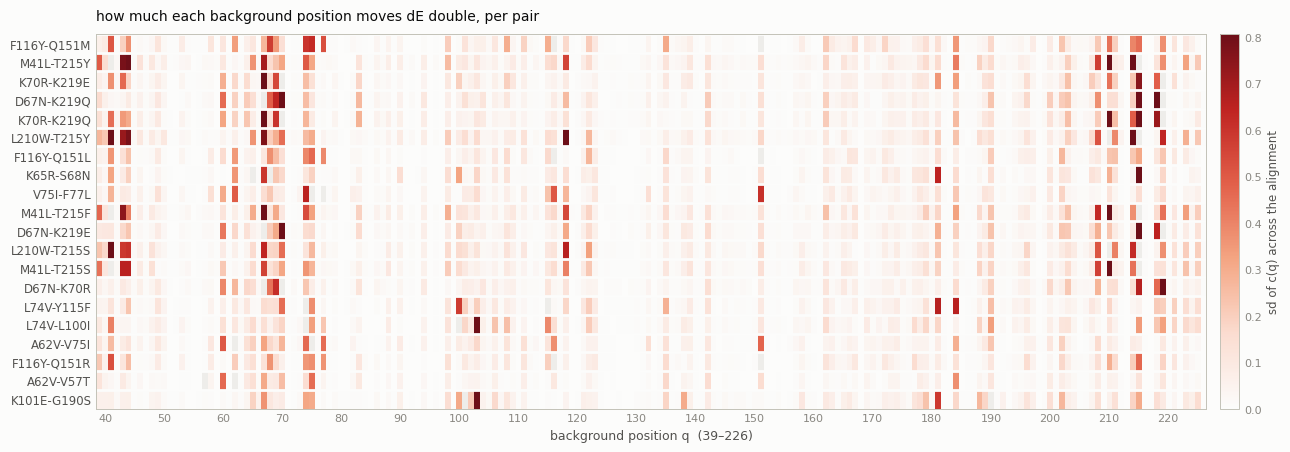

In [5]:
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

SURFACE, INK, INK2, MUTED, GRID, BASE = '#fcfcfb', '#0b0b0b', '#52514e', '#898781', '#e6e5df', '#c3c2b7'

plt.rcParams.update({'figure.facecolor': SURFACE, 'axes.facecolor': SURFACE,
                     'savefig.facecolor': SURFACE, 'font.size': 9, 'legend.frameon': False,
                     'axes.edgecolor': BASE, 'axes.linewidth': 0.7})

# Sequential, one hue, light -> dark: sd is a magnitude, so the darker the red the more that
# background position swings dE double. Anchored on the page surface so an sd of 0 reads as
# empty paper rather than as a colour.
REDS = LinearSegmentedColormap.from_list(
    'jterm_reds', ['#fcfcfb', '#fbdcd0', '#f4a582', '#e2604a', '#bf2321', '#6d0f18'])
REDS.set_bad('#eeedea')          # the pair's own two positions

# =============================================================================
# THE FIGURE -- every position's leverage, for every top pair, in one panel.
#
# Rows are the top 10 RT double mutations; columns are the 188 model positions, in sequence
# order. Each cell is the sd of that position's J-difference term c(q) for that pair. Dark
# red = a background position that really moves this pair's dE double; near-white = a
# position the pair does not care about. Grey = the pair's own two positions.
# =============================================================================
fig, ax = plt.subplots(figsize=(13.0, 4.6))

vmax = float(np.percentile(SD[SD > 0], 99.5))     # a couple of outliers should not flatten the rest
SD_PLOT = np.ma.masked_array(SD, mask=np.zeros_like(SD, dtype=bool))
for i, pair in enumerate(PAIRS):
    SD_PLOT.mask[i, list(SELF_POS[pair])] = True

im = ax.imshow(SD_PLOT, aspect='auto', cmap=REDS, vmin=0.0, vmax=vmax,
               interpolation='nearest',
               extent=[MIN_POS - 0.5, MAX_POS + 0.5, len(PAIRS) - 0.5, -0.5])

ax.set_yticks(range(len(PAIRS)), PAIRS, fontsize=8.5, color=INK2)
xt = np.arange(40, MAX_POS + 1, 10)
ax.set_xticks(xt, [str(t) for t in xt], fontsize=8, color=MUTED)
ax.set_xlabel(f'background position q  ({MIN_POS}–{MAX_POS})', color=INK2)
ax.set_title('how much each background position moves dE double, per pair',
             fontsize=10, color=INK, loc='left', pad=10)

ax.set_yticks(np.arange(len(PAIRS)) - 0.5, minor=True)
ax.grid(which='minor', axis='y', color=SURFACE, linewidth=2.0)   # 2px surface gap between rows
ax.tick_params(length=0, which='both')
for s in ax.spines.values():
    s.set_color(BASE)

cb = fig.colorbar(im, ax=ax, pad=0.012, fraction=0.026)
cb.set_label('sd of c(q) across the alignment', color=INK2, fontsize=8.5)
cb.outline.set_edgecolor(BASE)
cb.ax.tick_params(length=0, labelsize=8, colors=MUTED)

fig.tight_layout()
fig.savefig('jterm_sd_heatmap_RT_top10.png', dpi=400, bbox_inches='tight', pad_inches=0.03,
            facecolor=SURFACE)
fig.savefig('jterm_sd_heatmap_RT_top10.pdf', bbox_inches='tight', pad_inches=0.03,
            facecolor=SURFACE)
print('saved jterm_sd_heatmap_RT_top10.png / .pdf   (vmax =', round(vmax, 3), ')')
plt.show()

In [6]:
# The same numbers as a table, so nothing is readable only by colour: for each pair, the
# background positions with the largest sd of c(q).
TOPN = 8
readout = pd.DataFrame(
    {pair: [f'{POSITIONS[q]} ({SD[i, q]:.2f})' for q in np.argsort(-SD[i])[:TOPN]]
     for i, pair in enumerate(PAIRS)},
    index=[f'#{k + 1}' for k in range(TOPN)]).T
readout.index.name = 'pair'
SD_TABLE.to_csv('jterm_sd_by_position_RT_top10.csv')
print('saved jterm_sd_by_position_RT_top10.csv')
readout

saved jterm_sd_by_position_RT_top10.csv


,#1,#2,#3,#4,#5,#6,#7,#8
pair,,,,,,,,
F116Y-Q151M,75 (0.63),74 (0.60),68 (0.58),77 (0.53),41 (0.51),215 (0.45),210 (0.44),214 (0.40)
M41L-T215Y,210 (1.89),44 (0.83),214 (0.83),43 (0.78),67 (0.69),208 (0.57),118 (0.56),74 (0.50)
K70R-K219E,67 (2.20),215 (0.75),69 (0.55),218 (0.48),43 (0.46),210 (0.44),41 (0.37),181 (0.35)
D67N-K219Q,70 (1.97),218 (0.88),215 (0.80),69 (0.64),68 (0.49),60 (0.46),208 (0.37),83 (0.26)
K70R-K219Q,67 (2.34),215 (0.81),210 (0.81),218 (0.72),69 (0.60),214 (0.49),41 (0.45),43 (0.35)
L210W-T215Y,41 (2.45),214 (1.01),118 (0.80),44 (0.78),67 (0.77),43 (0.72),219 (0.64),208 (0.52)
F116Y-Q151L,75 (0.46),74 (0.39),77 (0.38),68 (0.37),41 (0.36),62 (0.35),215 (0.31),122 (0.27)
K65R-S68N,215 (0.87),181 (0.65),67 (0.59),62 (0.36),100 (0.32),41 (0.32),210 (0.29),69 (0.22)
V75I-F77L,74 (0.65),151 (0.61),116 (0.51),62 (0.49),60 (0.30),41 (0.28),118 (0.27),115 (0.23)
